In [1]:
# Import all required libraries
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

from tqdm import tqdm

print("✅ Step 1: Libraries imported successfully")

✅ Step 1: Libraries imported successfully


In [2]:
import gc

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gc.collect()
torch.cuda.empty_cache()

print(f"✅ Step 2: Using device → {device}")

✅ Step 2: Using device → cuda


In [3]:
# Define training parameters
BATCH_SIZE = 32
EPOCHS = 10
LR = 3e-5
WEIGHT_DECAY = 0.01
NUM_CLASSES = 2

print("✅ Step 3: Hyperparameters set")

✅ Step 3: Hyperparameters set


In [4]:
# Update these paths according to your dataset

train_dir = "/kaggle/input/datasets/dineshsonawane18/deepfake-mix/final_dataset/train"
val_dir   = "/kaggle/input/datasets/dineshsonawane18/deepfake-mix/final_dataset/val"
test_dir  = "/kaggle/input/datasets/dineshsonawane18/deepfake-mix/final_dataset/test"

print("✅ Step 4: Dataset paths loaded")

✅ Step 4: Dataset paths loaded


In [5]:
# Data augmentation for training
train_tfms = transforms.Compose([

    # 🔥 Core resize
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),

    # 🔁 Basic augmentations
    transforms.RandomHorizontalFlip(p=0.5),

    # 🎨 Color variations (simulate different lighting)
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.3,
        hue=0.1
    ),

    # 🔄 Rotation (face angle variation)
    transforms.RandomRotation(10),

    # 🔀 Slight geometric distortion
    transforms.RandomAffine(
        degrees=0,
        translate=(0.05, 0.05),
        shear=5
    ),

    # 🌫 Blur (simulate compression artifacts)
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),

    # ⚡ Random grayscale (helps detect texture anomalies)
    transforms.RandomGrayscale(p=0.1),

    # 🔥 Random Erasing (VERY POWERFUL)
    transforms.ToTensor(),

    transforms.RandomErasing(
        p=0.25,
        scale=(0.02, 0.1),
        ratio=(0.3, 3.3)
    ),

    # 📊 Normalization (ImageNet stats for ViT)
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

print("✅ Improved training transforms applied")

# Validation/test transforms (no augmentation)
val_tfms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

print("✅ Step 5: Transforms created")

✅ Improved training transforms applied
✅ Step 5: Transforms created


In [6]:
# Load dataset using ImageFolder
train_ds = datasets.ImageFolder(train_dir, transform=train_tfms)
val_ds   = datasets.ImageFolder(val_dir, transform=val_tfms)
test_ds  = datasets.ImageFolder(test_dir, transform=val_tfms)

#print("Classes:", train_ds.classes)
print(f"✅ Labels: {train_ds.class_to_idx}")
print("Train size:", len(train_ds))
print("Val size:", len(val_ds))
print("Test size:", len(test_ds))

print("✅ Step 6: Dataset loaded")

✅ Labels: {'fake': 0, 'real': 1}
Train size: 80000
Val size: 20000
Test size: 20000
✅ Step 6: Dataset loaded


In [7]:
# Create dataloaders
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)
test_loader  = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, pin_memory=True)

print("✅ Step 7: DataLoaders created")

✅ Step 7: DataLoaders created


In [8]:
class HybridViTCNN(nn.Module):

    def __init__(self, num_classes=2):
        super(HybridViTCNN, self).__init__()

        # 🔹 CNN Backbone (EfficientNet)
        self.cnn = models.efficientnet_b0(weights="IMAGENET1K_V1")
        cnn_out = self.cnn.classifier[1].in_features
        self.cnn.classifier = nn.Identity()  # remove head

        # 🔹 ViT Backbone
        self.vit = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
        vit_out = self.vit.heads.head.in_features
        self.vit.heads = nn.Identity()  # remove head

        # 🔹 Fusion Layer
       # Updated Fusion Layer in HybridViTCNN
        self.fc = nn.Sequential(
            nn.Linear(cnn_out + vit_out, 1024),
            nn.BatchNorm1d(1024), # Critical for balancing CNN/ViT scales
            nn.SiLU(),            # SiLU often performs better than ReLU for EfficientNet
            nn.Dropout(0.4),
            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.SiLU(),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):

        # CNN features
        cnn_feat = self.cnn(x)

        # ViT features
        vit_feat = self.vit(x)

        # Concatenate
        combined = torch.cat((cnn_feat, vit_feat), dim=1)

        # Final classification
        out = self.fc(combined)

        return out

In [9]:
model = HybridViTCNN(num_classes=2).to(device)

print("✅ Hybrid Model Ready")

✅ Hybrid Model Ready


In [10]:
# 1. Define weights to penalize missing "Fakes" (Class 1) more heavily
# [1.0, 2.5] means misclassifying a Fake is 2.5x more "expensive" than misclassifying a Real image
weights = torch.tensor([1.0, 2.5]).to(device)

# 2. Updated Loss function with weights AND label smoothing
criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)

# 3. Optimizer (best for ViT) - keeping your differential learning rates
optimizer = optim.AdamW([
    {'params': model.cnn.parameters(), 'lr': LR * 0.1},
    {'params': model.vit.parameters(), 'lr': LR * 0.1},
    {'params': model.fc.parameters(), 'lr': LR}
], weight_decay=WEIGHT_DECAY)

# 4. Scheduler
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

print("✅ Step 9: Weighted Loss, optimizer, and scheduler ready")

✅ Step 9: Weighted Loss, optimizer, and scheduler ready


In [11]:
from torch.amp import autocast, GradScaler

scaler = GradScaler("cuda")

print("✅ Step 10: Mixed precision enabled")

✅ Step 10: Mixed precision enabled


In [12]:
from tqdm import tqdm
from torch.amp import autocast

def train_one_epoch(epoch):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    print(f"\n🚀 Training Epoch {epoch+1}", flush=True)

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1} Training")

    for imgs, labels in pbar:

        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()

        # Mixed precision forward pass
        with autocast("cuda"):
            outputs = model(imgs)
            loss = criterion(outputs, labels)

        # Backpropagation
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # Live update in tqdm
        pbar.set_postfix({
            "Loss": f"{loss.item():.4f}",
            "Acc": f"{correct/total:.4f}"
        })

    epoch_loss = total_loss / len(train_loader)
    epoch_acc = correct / total

    print(f"✅ Train Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}", flush=True)

    return epoch_acc

In [13]:
def validate(epoch):

    model.eval()

    correct = 0
    total = 0

    print(f"\n🔍 Validating Epoch {epoch+1}", flush=True)

    with torch.no_grad():

        for imgs, labels in tqdm(val_loader, desc="Validating"):

            imgs, labels = imgs.to(device), labels.to(device)

            outputs = model(imgs)

            preds = torch.argmax(outputs, dim=1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)
            
    val_acc = correct / total

    print(f"✅ Validation Accuracy: {val_acc:.4f}", flush=True)

    return val_acc

In [14]:
best_acc = 0

train_accs = []
val_accs = []

print("🚀 Starting Training...\n", flush=True)

for epoch in range(EPOCHS):

    print(f"\n==============================")
    print(f"🚀 Epoch {epoch+1}/{EPOCHS}")
    print(f"==============================")

    # ✅ Pass epoch here
    train_acc = train_one_epoch(epoch)
    val_acc = validate(epoch)

    scheduler.step()

    train_accs.append(train_acc)
    val_accs.append(val_acc)

    # Save best model
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), "Hybrid_vit.pth")
        print("💾 ✅ Best model saved!", flush=True)

print("\n🎉 Training complete!", flush=True)

🚀 Starting Training...


🚀 Epoch 1/10

🚀 Training Epoch 1


Epoch 1 Training: 100%|██████████| 2500/2500 [36:55<00:00,  1.13it/s, Loss=0.2884, Acc=0.8756]

✅ Train Loss: 0.3292, Accuracy: 0.8756

🔍 Validating Epoch 1



Validating: 100%|██████████| 625/625 [08:46<00:00,  1.19it/s]

✅ Validation Accuracy: 0.9506


...

✅ Validation Accuracy: 0.9709

🚀 Epoch 10/10

🚀 Training Epoch 10



Epoch 10 Training: 100%|██████████| 2500/2500 [36:42<00:00,  1.14it/s, Loss=0.2104, Acc=0.9767]

✅ Train Loss: 0.2153, Accuracy: 0.9767

🔍 Validating Epoch 10



Validating: 100%|██████████| 625/625 [06:18<00:00,  1.65it/s]

✅ Validation Accuracy: 0.9731

🎉 Training complete!


In [15]:
def test_model():

    model.load_state_dict(torch.load("Hybrid_vit.pth"))

    model.eval()

    all_labels, all_preds, all_probs = [], [], []

    with torch.no_grad():

        for imgs, labels in test_loader:

            imgs = imgs.to(device)

            outputs = model(imgs)

            probs = torch.softmax(outputs,1)

            preds = torch.argmax(outputs,1)

            all_labels.extend(labels.numpy())
            all_preds.extend(preds.cpu().numpy())
            all_probs.extend(probs[:,1].cpu().numpy())

    print("✅ Testing complete")

    return all_labels, all_preds, all_probs

In [16]:
labels, preds, probs = test_model()

print("✅ Evaluation data ready")

✅ Testing complete
✅ Evaluation data ready


Confusion Matrix:
 [[9752  248]
 [ 209 9791]]


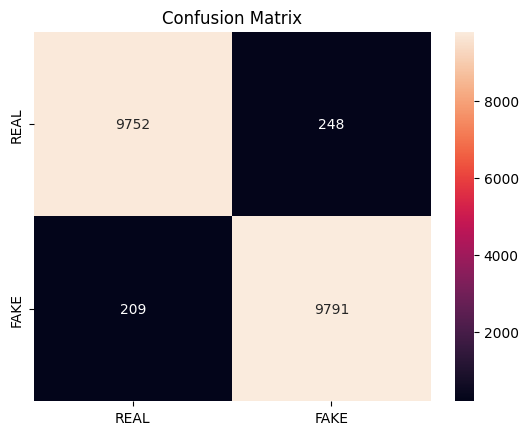

In [17]:
cm = confusion_matrix(labels, preds)

print("Confusion Matrix:\n", cm)

sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["REAL","FAKE"],
            yticklabels=["REAL","FAKE"])

plt.title("Confusion Matrix")
plt.show()

In [18]:
print(classification_report(labels, preds))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     10000
           1       0.98      0.98      0.98     10000

    accuracy                           0.98     20000
   macro avg       0.98      0.98      0.98     20000
weighted avg       0.98      0.98      0.98     20000



AUC Score: 0.997265985


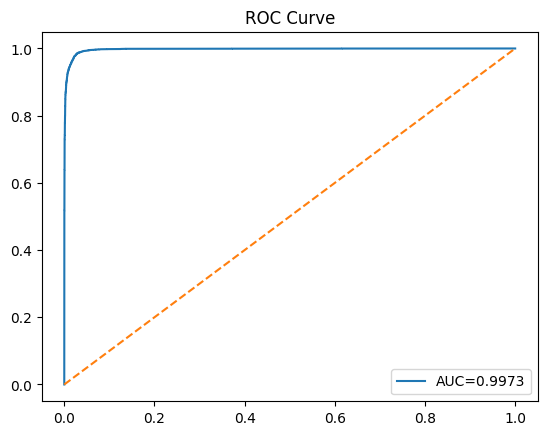

In [19]:
auc = roc_auc_score(labels, probs)

print("AUC Score:", auc)

fpr, tpr, _ = roc_curve(labels, probs)

plt.plot(fpr, tpr, label=f"AUC={auc:.4f}")
plt.plot([0,1],[0,1],'--')

plt.legend()
plt.title("ROC Curve")

plt.show()

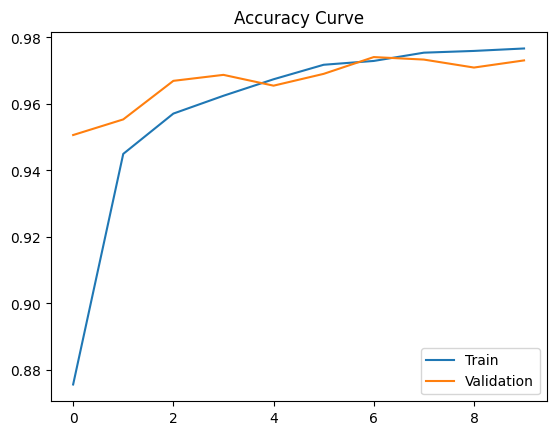

✅ All steps completed successfully


In [20]:
plt.plot(train_accs,label="Train")
plt.plot(val_accs,label="Validation")

plt.legend()
plt.title("Accuracy Curve")

plt.show()

print("✅ All steps completed successfully")